# Parameter Inference

In this notebook, we demonstrate the steps to conduct parameter inference using our data-adaptive ODE solver, `dalton`.

In [2]:
import jax
import jax.numpy as jnp
import numpy as np
from scipy.integrate import odeint
from jax import jacfwd, jacrev
from jaxopt import ScipyMinimize

from rodeo.ibm import ibm_init
from rodeo.ode import interrogate_tronarp
from rodeo.fenrir import *
from rodeo.dalton import loglikehood

import matplotlib.pyplot as plt
import seaborn as sns
from jax.config import config
config.update("jax_enable_x64", True)

We will use the FitzHugh-Nagumo model as the example here which is a two-state ODE on $\xx(t) = (V(t), R(t))$,

\begin{align*}
\frac{dV(t)}{dt} &= c(V(t) - \frac{V(t)^3}{3} + R(t)), \\
\frac{dR(t)}{dt} &= -\frac{(V(t) - a - bR(t))}{c}. \\
\end{align*}

The model parameters are $\tth = (a,b,c,V(0),R(0))$, with $a,b,c > 0$ which are to be learned from the measurement model

\begin{align*}
\YY_i \sim \N(\xx(t_i), \phi^2 \Id_{2 \times 2})
\end{align*}

where $t_i = i$ and $i=0,1,\ldots 40$ and $\phi^2 = 0.005$. We will first simulate some noisy data using an highly accurate ODE solver (`odeint`).

In [3]:
def fitz0(X_t, t, theta):
    a, b, c = theta
    V, R = X_t 
    return np.array([c*(V - V*V*V/3 + R), -1/c*(V - a + b*R)])

# it is assumed that the solution is sought on the interval [tmin, tmax].
tmin = 0.
tmax = 40.
theta = np.array([0.2, 0.2, 3])

# Initial x0 for odeint
ode0 = np.array([-1., 1.])

# observations
n_obs = 40
tseq = np.linspace(tmin, tmax, n_obs+1)
exact = odeint(fitz0, ode0, tseq, args=(theta,))
gamma = np.sqrt(.005)
e_t = np.random.default_rng(0).normal(loc=0.0, scale=1, size=exact.shape)
obs = exact + gamma*e_t

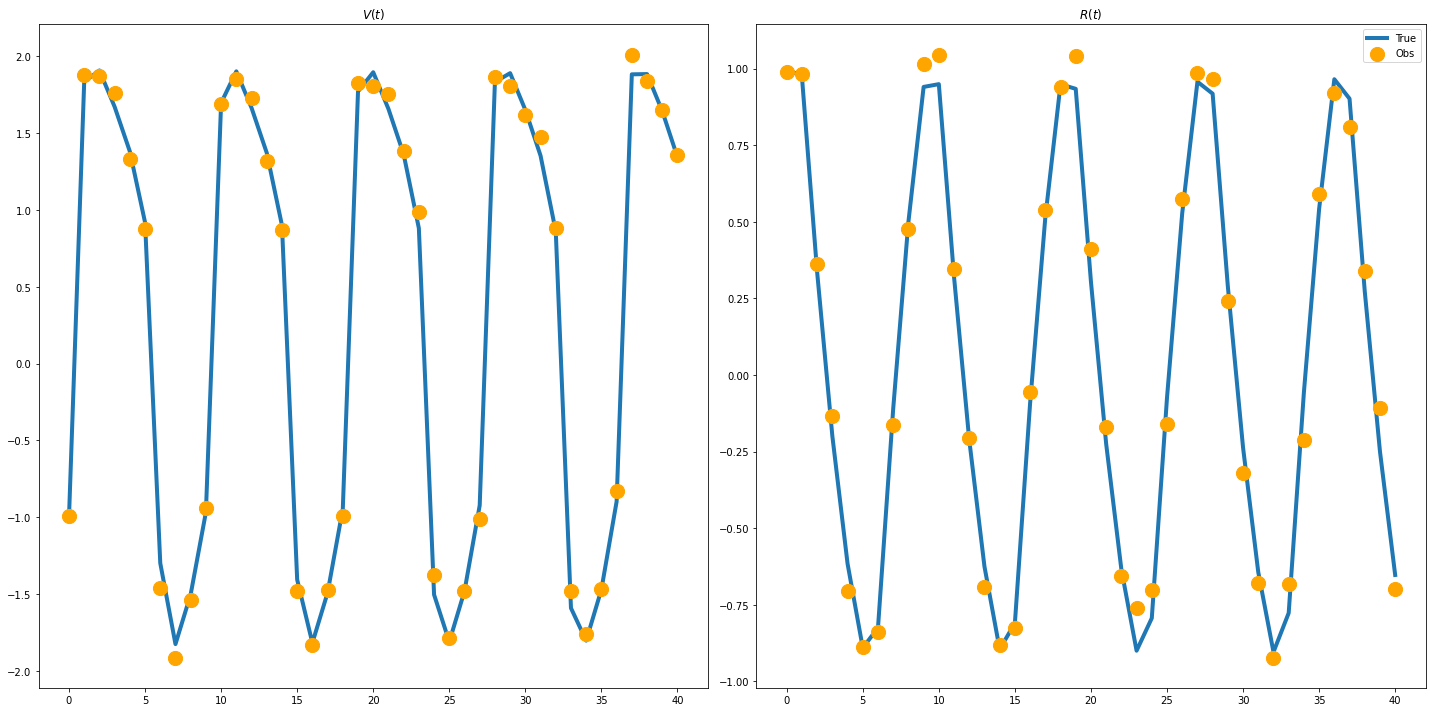

In [4]:
# plot one graph
plt.rcParams.update({'font.size': 30})
fig1, axs = plt.subplots(1, 2, figsize=(20, 10))
axs[0].plot(tseq, exact[:,0], label = 'True', linewidth=4)
axs[0].scatter(tseq, obs[:,0], label = 'Obs', color='orange', s=200, zorder=2)
axs[0].set_title("$V(t)$")
axs[1].plot(tseq, exact[:,1], label = 'True', linewidth=4)
axs[1].scatter(tseq, obs[:,1], label = 'Obs', color='orange', s=200, zorder=2)
axs[1].set_title("$R(t)$")
axs[1].legend(loc=1)
fig1.tight_layout()

We now need to define the specifications for `dalton`. In particular, `dalton` uses variable blocking to be more computationally efficient (read more about this in our paper). `dalton` expects observations to be of the form

\begin{equation*}
\YY_i \sim \N(\DD \XX_i + \cc, \OOm).
\end{equation*}
This translates to the following set of definitions for this 2-state ODE.

In [5]:
# format observations to be taken by DALTON
y_obs = jnp.expand_dims(obs, -1) 
trans_obs = jnp.array([[[1., 0., 0.]], [[1., 0., 0.]]]) 
mean_obs = jnp.zeros((2, 1))
var_obs = gamma**2*jnp.array([[[1.]],[[1.]]])

Similar to `rodeo`, we need to define the Gaussian Markov process prior using the IBM. Other choices are possible, however, we have made this simple prior available in the library. The rest of the inputs are the same as `rodeo` with `n_steps` replaced with `n_res`. This variable simply defines the resolution of the solution based on the observations. For example, `n_res=10` in this ODE would give `n_step = 10 * 40 = 400`.

In [6]:
def fitz(X_t, t, theta):
    "Fitz ODE written for jax"
    a, b, c = theta
    V, R = X_t[:, 0]
    return jnp.array([[c*(V - V*V*V/3 + R)],
                      [-1/c*(V - a + b*R)]])
# ode parameter 
theta = jnp.array([0.2, 0.2, 3])

# problem setup and intialization
n_deriv = 1  # Total state; q
n_var = 2  # Total variables
n_deriv_prior = 3 # p

# tuning parameter in the IBM process
sigma = jnp.array([10]*n_var) 

# block definition for W, and x0
W = jnp.array([[[0., 1., 0.]], [[0., 1., 0.]]])  # ODE LHS matrix
x0 = jnp.array([[-1., 1., 0.], [1., 1/3, 0.]])

# Get parameters needed to run the solver
n_res = 10
n_steps = n_obs*n_res
dt = (tmax-tmin)/n_steps
n_order = jnp.array([n_deriv_prior]*n_obs)
ode_init = ibm_init(dt, n_order, sigma)

# prng key
key = jax.random.PRNGKey(0)

In [7]:
lp = loglikehood(key=key, fun=fitz, W=W, x0=x0, theta=theta, 
                 tmin=tmin, tmax=tmax, n_res=n_res,
                 trans_state=ode_init['trans_state'], mean_state=ode_init['mean_state'], var_state=ode_init['var_state'],
                 trans_obs=trans_obs, mean_obs=mean_obs, var_obs=var_obs, y_obs=y_obs, interrogate=interrogate_tronarp)
lp

DeviceArray(104.76499447, dtype=float64)

We proceed with a Bayesian approach by postulating a prior distribution $\pi(\tth)$ which combined with the likelihood gives the posterior
\begin{equation*}
    p(\tth \mid \YY_{0:M}) \propto \pi(\tth) \times p(\YY_{0:M} \mid \ZZ_{0:N} = \bz, \tth)
\end{equation*}
where $p(\YY_{0:M} \mid \ZZ_{0:N} = \bz, \tth)$ is computed using DALTON.
Parameter inference is then accomplished by way of a Laplace approximation, for which we have
\begin{equation*}
    \tth \mid \YY_{0:M} \approx \N(\hat \tth, \hat \VV_{\tth}),
\end{equation*}
where $\hat \tth = \argmax_{\tth} \log p(\tth \mid \YY_{0:M})$ and $\hat \VV_{\tth} = -\big[\frac{\partial^2}{\partial \tth \partial \tth'} \log p(\hat \tth \mid \YY_{0:M})\big]^{-1}$.

We define the prior and posterior functions necessary to conduct parameter inference. The key function to focus is `dalton_nlpost` which takes in `phi = (log a, log b, log c, V(0), R(0))`. It uses the ODE and the $V(0), R(0)$ to compute the  $dV(0), dR(0)$ required for `dalton` and then zero pad it an extra dimension which helps with accuracy. The other three parameters $\log a, \log b, \log c$ needs to be exponentiated first before it is input to `dalton` since `dalton` assumes they are on the regular scale. The function `phi_fit` essentially computes the Laplace approximation detailed above. We use the **jaxopt** library as it supports optimization using **jax**. We choose `Newton-CG` as our optimization algorithm but there are many other possible choices. Consult the **jaxopt** documentation if you are interested in this library.

In [36]:
def logprior(x, mean, sd):
    r"Calculate the loglikelihood of the normal distribution."
    return jnp.sum(jsp.stats.norm.logpdf(x=x, loc=mean, scale=sd))

def nlpost(phi):
    r"Compute the negative loglikihood of :math:`Y_t` using DALTON."
    x0 = phi[n_theta:].reshape((2,1))
    theta = jnp.exp(phi[:n_theta])
    v0 = fitz(x0, 0, theta)
    x0 = jnp.hstack([x0, v0, jnp.zeros(shape=(x0.shape))])
    lp = loglikehood(key, fitz, W, x0, theta, tmin, tmax, n_res,
            ode_init['trans_state'], ode_init['mean_state'], ode_init['var_state'],
            trans_obs, mean_obs, var_obs, y_obs, interrogate_tronarp)
    lp += logprior(phi, phi_mean, phi_sd)
    return -lp

def phi_fit(phi_init):
    r"""Compute the optimized :math:`\log{\theta}` and its variance given 
        :math:`Y_t`."""
    n_phi = len(phi_init)
    hes = jacfwd(jacrev(nlpost))
    solver = ScipyMinimize(method="Newton-CG", fun = nlpost)
    opt_res = solver.run(phi_init)
    phi_hat = opt_res.params
    phi_fisher = hes(phi_hat)
    phi_var = jsp.linalg.solve(phi_fisher, jnp.eye(n_phi))
    return phi_hat, phi_var

def phi_sample(phi_hat, phi_var, n_samples):
    r"""Simulate :math:`\theta` given the :math:`\log{\hat{\theta}}` 
        and its variance."""
    phi = np.random.default_rng(12345).multivariate_normal(phi_hat, phi_var, n_samples)
    return phi

We will assume independent $\N(0, 10^2)$ priors on $\log a, \log b, \log c$ and $V(0), R(0)$.

In [44]:
# logprior parameters
theta_true = jnp.array([0.2, 0.2, 3]) # True theta
n_phi = 5
phi_mean = jnp.zeros(n_phi)
phi_sd = jnp.log(10)*jnp.ones(n_phi) 
n_theta = 3
n_samples = 100000

# optimization process
phi_init = jnp.append(jnp.log(theta_true), ode0)
phi_hat, phi_var = phi_fit(phi_init)
theta_post = phi_sample(phi_hat, phi_var, n_samples)
theta_post[:, :n_theta] = np.exp(theta_post[:, :n_theta])

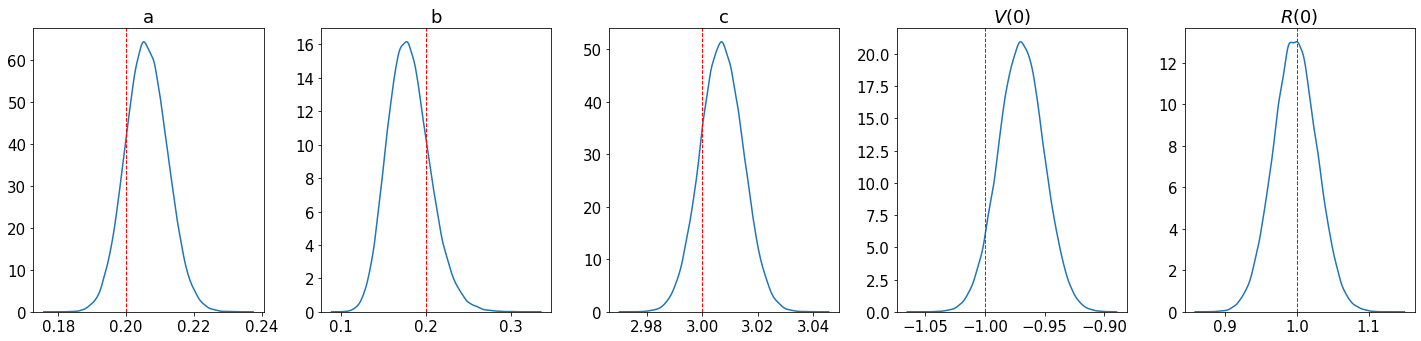

In [51]:
plt.rcParams.update({'font.size': 15})
param_true = np.append(theta_true, ode0)
var_names = ['a', 'b', 'c', r"$V(0)$", r"$R(0)$"]
fig, axs = plt.subplots(1, 5, figsize=(20,5))
for i in range(5):
    sns.kdeplot(theta_post[:, i], ax=axs[i])
    axs[i].axvline(x=param_true[i], linewidth=1, color='r', linestyle='dashed')
    axs[i].set_ylabel("")
    axs[i].set_title(var_names[i])
fig.tight_layout()